[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nrao/astrohack/blob/v1.0.0/docs/locit_tutorial.ipynb)

![astrohack](astrohack_logo.png)

# Antenna position correction tutorial

`extract_locit` and `locit` are utilities designed to help determine antenna position shifts after antenna relocation.
To do so they rely on a phase gain calibration table created by `CASA` from antenna pointing data.
The process in `CASA` consists of:
1. `split` out the actual pointing data from the original pointing measurement set (MS), it might contain data taken while the antennas are still slewing.
2. `fringe_fit` the MS using a single source with no delay rates, this is done to flatten a spectral window.
3. `apply_cal` the fringe_fit solution.
4. Channel average the MS using `split`.
5. Compute an average phase gain solution for each source using `gaincal`

To simplify the process in `CASA` a script is distributed within `astrohack` that the user can simply fill in the parameters for the data reduction and then run it within `CASA`.


In [1]:
import os

try:
    import astrohack

    print("AstroHACK version", astrohack.__version__, "already installed.")
except ImportError as e:
    print(e)
    print("Installing AstroHACK")

    os.system("pip install astrohack")

    import astrohack

    print("astrohack version", astrohack.__version__, " installed.")

AstroHACK version 1.0.0 already installed.


## Download Tutorial data

In [2]:
# The Cal table used here is a placeholder, there should be a better dataset to be used with the tutorial
import toolviper

toolviper.utils.data.download(file="locit-input-pha.cal", folder="data")

[2026-03-05 16:59:29,567]     INFO   astrohack:  Module path: /home/victor/mambaforge/envs/casadev/lib/python3.12/site-packages/toolviper 


[2026-03-05 16:59:29,575]     INFO   astrohack:  Downloading from [cloudflare] .... 


 Download List        
 ───────────────────── 
  locit-input-pha.cal

Output()

## Position and locit Data File API

As part of the `astroHACK` API a set of functions to allow users to easily open on disk locit and position files has been provided. Each function takes an `astroHACK` locit or position file name as an argument and returns an object related to the given file type. Each object allows the user to access data via dictionary keys with values consisting of the relevant dataset. Each object also provides a `summary()` helper function to list available keys for each file. An example call for each file type is show below and the API documentation for all data-io functions can be found [here](https://astrohack.readthedocs.io/en/latest/_api/autoapi/astrohack/dio/index.html).

```python
from astrohack import open_locit
from astrohack import open_position

locit_data = open_locit(file='./data/locit-input-pha.locit.zarr')
position_data = open_position(file='./data/locit-input-pha.position.zarr')
```

## Setup Dask Local Cluster

The local Dask client handles scheduling and worker managment for the parallelization. The user has the option of choosing the number of cores and memory allocations for each worker howerver, we recommend a minimum of 1Gb per core with standard settings.


A significant amount of information related to the client and scheduling can be found using the [Dask Dashboard](https://docs.dask.org/en/stable/dashboard.html). This is a built-in dashboard native to Dask and allows the user to monitor the workers during processing. This is especially useful for profilling. For those that are interested in working soley within Jupyterlab a dashboard extension is available for [Jupyterlab](https://github.com/dask/dask-labextension#dask-jupyterlab-extension).

![dashboard](../_media/dashboard.png)

In [3]:
from toolviper.dask.client import local_client

parallel = True

if parallel:
    client = local_client(cores=4, memory_limit="1GB")
    print(client)
else:
    client = None


[2026-03-05 16:59:30,004]     INFO   astrohack:  Module path: /home/victor/mambaforge/envs/casadev/lib/python3.12/site-packages/toolviper 


[2026-03-05 16:59:30,008]  WARNING   astrohack:  It is recommended that the local cache directory be set using the dask_local_dir parameter. 


[2026-03-05 16:59:31,167]     INFO   astrohack:  Client <MenrvaClient: 'tcp://127.0.0.1:41621' processes=4 threads=4, memory=3.73 GiB> 


<MenrvaClient: 'tcp://127.0.0.1:41621' processes=4 threads=4, memory=3.73 GiB>


## Extract locit

The first step in determining the antenna position corrections is to extract the data from the phase gains calibration table and store it in a convenient format for further processing.

In the calibration table the data is organized by time, but we want organized by antenna → DDI → time for simplicity of processing in `locit`.

Also, the data in the calibration table may contain more than one reference antenna, which would scramble the results obtained by `locit`, hence we throw away data that has a different reference antenna than the main reference antenna in `extract_locit`

In [4]:
cal_table = "./data/locit-input-pha.cal"
locit_name = "./data/locit-input-pha.locit.zarr"
position_name = "./data/locit-input-pha.position.zarr"

In [5]:
%%time
from astrohack import extract_locit

locit_mds = extract_locit(
    cal_table,  # The calibration table containing the phase gains
    locit_name=locit_name,  # The name for the created locit file
    ant="all",  # Antenna selection, None means 'All'
    ddi="all",  # DDI selection, None means 'ALL'
    overwrite=True,
)

[2026-03-05 16:59:31,179]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


[2026-03-05 16:59:31,182]     INFO   astrohack:  Creating output file name: ./data/locit-input-pha.locit.zarr 


[2026-03-05 16:59:32,136]     INFO   astrohack:  Consolidating ./data/locit-input-pha.locit.zarr... 


CPU times: user 1.58 s, sys: 219 ms, total: 1.8 s
Wall time: 1.76 s


`extract_locit` creates a file that is called a locit file. This file contains the phase gains for each antenna but also contains two important tables, the source and antenna tables.

`extract_locit` also returns the opened locit file as a `locit_mds` object. The first step in interacting with the `locit_mds` object is calling its summary

In [6]:
locit_mds.summary()

################################################################################
###                               Summary for:                               ###
###                    ./data/locit-input-pha.locit.zarr                     ###
################################################################################

Data origin:
creation_time:    2026-03-05 16:59:31 MST
creator_function: extract_locit
origin:           astrohack
version:          1.0.0

Input Parameters:
+------------+-----------------------------------+
| Parameter  | Value                             |
+------------+-----------------------------------+
| ant        | all                               |
| cal_table  | ./data/locit-input-pha.cal        |
| ddi        | all                               |
| locit_name | ./data/locit-input-pha.locit.zarr |
| overwrite  | True                              |
+------------+-----------------------------------+

Available methods:
+------------------------------+------

From the summary, we can see that the locit file contains 26 antennas and 2 DDIs per antenna, as well as 4 different methods related to the visualization of the source and antenna tables. To inspect the data contained in a DDI for an antenna, we simply access the dictionary keys as so,

In [7]:
locit_mds["ant_ea06"]["ddi_0"]

<xarray.DataTree 'ddi_0'>
Group: /ant_ea06/ddi_0
    Dimensions:         (p0_time: 33, p1_time: 34)
    Coordinates:
      * p0_time         (p0_time) float64 264B 6.018e+04 6.018e+04 ... 6.018e+04
      * p1_time         (p1_time) float64 272B 6.018e+04 6.018e+04 ... 6.018e+04
    Data variables:
        P0_PHASE_GAINS  (p0_time) float32 132B 0.2488 0.6855 ... 0.9096 -0.7223
        P0_FIELD_ID     (p0_time) int32 132B 0 1 2 3 4 5 6 ... 19 13 25 26 27 28 29
        P1_PHASE_GAINS  (p1_time) float32 136B 0.2527 0.6873 ... 0.9876 -0.7128
        P1_FIELD_ID     (p1_time) int32 136B 0 1 2 3 4 5 6 ... 19 13 25 26 27 28 29
    Attributes:
        frequency:            8223000000.0
        bandwidth:            [128000000.0]
        polarization_scheme:  ['R', 'L']

### Inspecting the Sources in the dataset

When trying to determine the antenna position correction, we are always interested in knowing the distribution in the sky of the sources used in the pointing observation. The antenna position corrections in X and Y are affected by the hour-angle coverage of the observations, while the Z position correction is affected by the declination coverage of the observations.

First we will print the source table, and second we will plot the sources on a simplified sky plot for easier visualization.

In [8]:
locit_mds.print_source_table()


Sources:
+----+----------+---------------+----------------+---------------+----------------+
| Id | Name     | RA FK5        | DEC FK5        | RA precessed  | DEC precessed  |
+----+----------+---------------+----------------+---------------+----------------+
| 0  | 2023+544 | 20h23m55.833s | +54°27m35.789s | 20h23m21.769s | +54°32m16.844s |
| 1  | 2005+778 | 20h05m30.999s | +77°52m43.247s | 20h03m29.593s | +77°56m51.192s |
| 10 | 1957-387 | 19h57m59.819s | -38°45m06.356s | 19h58m23.302s | -38°41m20.677s |
| 11 | 2109-411 | 21h09m33.189s | -41°10m20.605s | 21h09m53.676s | -41°04m35.841s |
| 12 | 2158-150 | 21h58m06.282s | -15°01m09.327s | 21h58m11.952s | -14°54m20.025s |
| 13 | 2212+239 | 22h12m05.966s | +23°55m40.543s | 22h12m00.818s | +24°02m43.254s |
| 14 | 0010+174 | 00h10m33.991s | +17°24m18.762s | 00h10m35.414s | +17°32m13.416s |
| 15 | 0204-170 | 02h04m57.674s | -17°01m19.840s | 02h04m53.468s | -16°54m21.691s |
| 16 | 0339-017 | 03h39m30.938s | -01°46m35.803s | 03h39m30.282s |

[2026-03-05 16:59:32,980]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


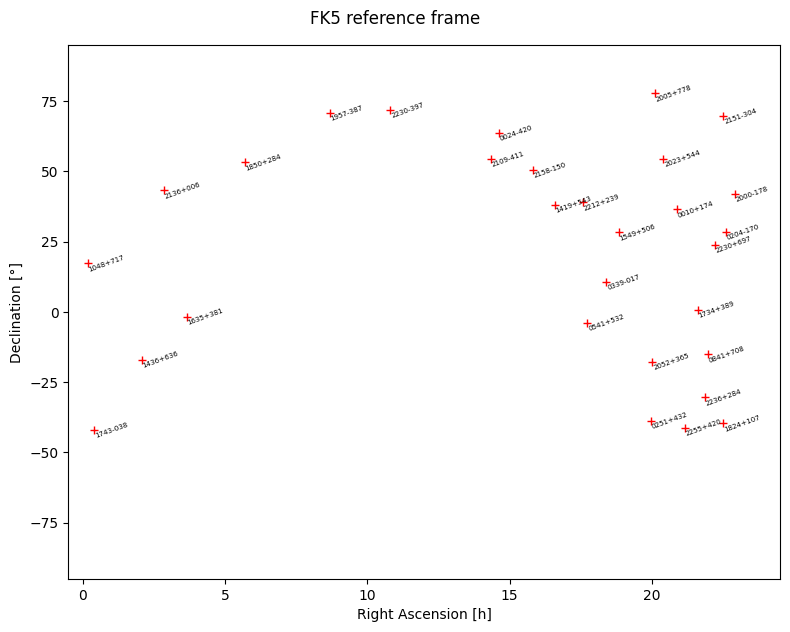

In [9]:
locit_plot_folder = "locit_mds_plots"

locit_mds.plot_source_positions(
    locit_plot_folder,  # destination for the plot
    labels=True,  # Display source labels on plot
    precessed=False,  # Plot FK5 (J2000) coordinates instead of precessed coordinates
    display=True,
)

### Inspecting the array configuration in the dataset

Another important piece of information when determining antenna position corrections is which antennas are present in the observations and where are they located in the array. We have introduced two methods to display this information, the first, `print_array_configuration`, displays all the antennas for the array, accompanied by their positions if they are present in the dataset. The second method, `plot_array_configuration`, plots the positions of the antennas in the dataset; antennas not present are simply skipped.

In [10]:
locit_mds.print_array_configuration(
    relative=False
)  # antenna positions printed are relative to the array center

[2026-03-05 16:59:33,629]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 



EVLA antennas, # of antennas 26:
+------+---------+-----------------+----------------+--------------+
| Name | Station |    Longitude    |    Latitude    |  Radius [m]  |
+------+---------+-----------------+----------------+--------------+
| ea01 |   W32   | -107°39m54.777s | +33°52m27.200s | 6373591.7591 |
| ea02 |   N72   | -107°38m10.526s | +34°04m12.216s | 6373536.5113 |
| ea03 |   N/A   |       N/A       |      N/A       |     N/A      |
| ea04 |   E48   | -107°30m56.082s | +33°51m38.381s | 6373617.9185 |
| ea05 |   W40   | -107°41m13.482s | +33°51m43.069s | 6373588.2127 |
| ea06 |   MAS   | -107°37m41.283s | +33°53m41.999s | 6373580.9899 |
| ea07 |   E16   | -107°36m09.822s | +33°53m40.005s | 6373579.2062 |
| ea08 |   N56   | -107°37m47.893s | +34°00m38.380s | 6373545.7480 |
| ea09 |   W24   | -107°38m49.036s | +33°53m04.046s | 6373590.5071 |
| ea10 |   N40   | -107°37m29.504s | +33°57m44.409s | 6373559.2211 |
| ea11 |   W56   | -107°44m26.689s | +33°49m54.626s | 6373595.3443 |


[2026-03-05 16:59:33,640]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


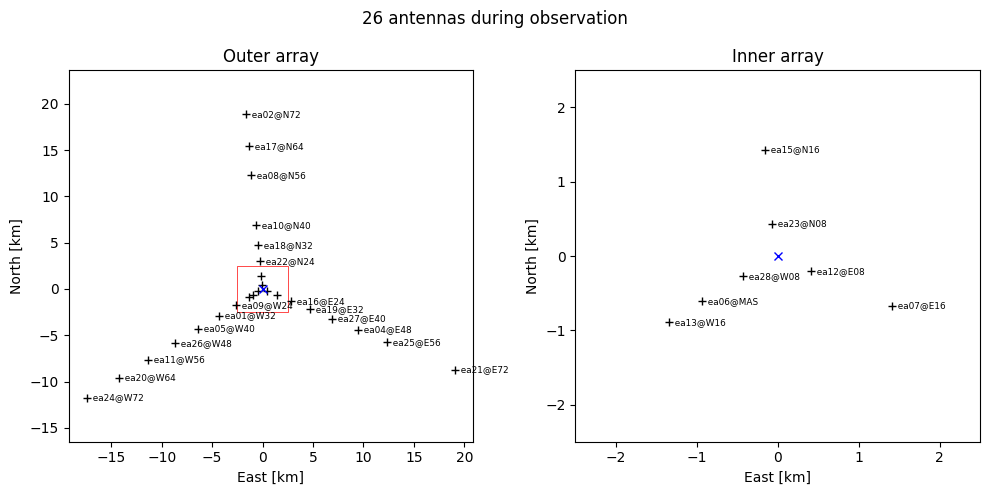

In [11]:
locit_mds.plot_array_configuration(
    locit_plot_folder,  # Folder in which to save the plot
    stations=True,  # Toggle to display the station name alongside the antenna name
    zoff=False,  # Toggle to display the antenna elevation offset by its name
    unit="km",  # Length unit for the plot
    box_size=5,  # Size of the box for the inner array in the unit specified in unit
    display=True,
)

## Locit

After we have inspected the `locit_mds` object we can now use `locit` to obtain antenna position corrections. In this dataset a single antenna, ea06 has been moved, and hence we could skip the other antennas and get position corrections for only it and the reference antenna, ea28. 
But here we will be getting corrections for all antennas as this can help point out systematic errors with the dataset, such as choosing a bad reference antenna.
We include the reference antenna in the fit as a sanity check, the position corrections for the reference antenna, as well as the fixed delay and delay rate are by construction, 0, if they aren't there is something wrong with the code.

In [12]:
%%time
from astrohack import locit

position_mds = locit(
    locit_name,
    position_name=position_name,  # Name of the position file to be created by locit
    elevation_limit=10.0,  # Elevation under which no sources are considered
    polarization="both",  # Combine both R and L polarization phase gains for increased SNR
    fit_engine="scipy",  # Fit data using scipy
    fit_kterm=False,
    fit_delay_rate=True,  # Fit delay rate
    ant="all",  # Select all antennas
    ddi="all",  # Select all DDIs
    combine_ddis="simple",  # Combine delays from all DDIs to obtain a single solution with increased SNR
    parallel=parallel,  # Do fitting in parallel
    overwrite=True,  # Overwrite previously created position file
)

[2026-03-05 16:59:34,477]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


[2026-03-05 16:59:34,482]     INFO   astrohack:  Creating output file name: ./data/locit-input-pha.position.zarr 


[2026-03-05 16:59:42,557]     INFO   astrohack:  Consolidating ./data/locit-input-pha.position.zarr... 


CPU times: user 4.06 s, sys: 244 ms, total: 4.3 s
Wall time: 8.27 s


`locit` creates a file that is called a position file. This file contains the delays, and the fitted delay model for each antenna

`locit` also returns the opened position file as a `position_mds` object. The first step in interacting with the `position_mds` object is calling its summary

In [13]:
position_mds.summary()

################################################################################
###                               Summary for:                               ###
###                   ./data/locit-input-pha.position.zarr                   ###
################################################################################

Data origin:
creation_time:    2026-03-05 16:59:34 MST
creator_function: locit
origin:           astrohack
version:          1.0.0

Input Parameters:
+-----------------+--------------------------------------+
| Parameter       | Value                                |
+-----------------+--------------------------------------+
| ant             | all                                  |
| combine_ddis    | simple                               |
| ddi             | all                                  |
| elevation_limit | 10.0                                 |
| fit_delay_rate  | True                                 |
| fit_engine      | scipy                            

From the summary we can see that the position file contains simply 2 antennas and no DDIs, as well as 4 different methods:
- `export_fit_results` exports the antenna position corrections to an ascii file.
- `plot_sky_coverage` plots the sky coverage for an antenna and DDI (if present).
- `plot_delays` plots the measured delays as a function of time, hour angle, declination and elevation,
- `plot_position_corrections` Plots the position corrections on an array plot, making it easier to identify systematics

To inspect the data contained in the position file for an antenna we can then simply do:

In [14]:
position_mds["ant_ea06"]

<xarray.DataTree 'ant_ea06'>
Group: /ant_ea06
    Dimensions:      (time: 110)
    Coordinates:
      * time         (time) float64 880B 0.0 0.002234 0.004711 ... 0.07838 0.07992
    Data variables:
        DECLINATION  (time) float64 880B dask.array<chunksize=(110,), meta=np.ndarray>
        DELAYS       (time) float32 440B dask.array<chunksize=(110,), meta=np.ndarray>
        ELEVATION    (time) float64 880B dask.array<chunksize=(110,), meta=np.ndarray>
        HOUR_ANGLE   (time) float64 880B dask.array<chunksize=(110,), meta=np.ndarray>
        LST          (time) float64 880B dask.array<chunksize=(110,), meta=np.ndarray>
        MODEL        (time) float64 880B dask.array<chunksize=(110,), meta=np.ndarray>
    Attributes:
        antenna_info:       {'geocentric_position': [-1602152.0314, -5042031.7101...
        chi_squared:        3.4313970729134775e-23
        elevation_limit:    0.17453292519943295
        fixed_delay_error:  2.133277279072697e-12
        fixed_delay_fit:    2.5331243787608035e-11
        frequency:          [8223000000.0, 8823000000.0]
        polarization:       both
        position_error:     [1.752881936360318e-12, 1.4090763078794412e-12, 1.552...
        position_fit:       [-2.989452149668351e-11, -1.225892544315829e-11, -5.1...
        rate_error:         2.7610888392274874e-11
        rate_fit:           8.518928473107703e-12

The following plot of the sky coverage of the sources for antenna ea06, gives us an idea of how good our results can be. From it we see that basically all possible hour-angles and declinations are covered, which implies that the position correction determinations are as good as they can be given the observing conditions are good and stable enough.

Weather may complicate this measurement by introducing anisotropic and time dependant delays, limiting the methods accuracy.

In [15]:
position_plot_folder = "position_mds_exports"

position_mds.plot_sky_coverage(
    position_plot_folder,  # Folder to contain plot
    ant="ea06",  # Plot only antenna ea06
    ddi="all",  # DDI selection irrelevant because we are combining DDIs
    time_unit="hour",  # Unit for observation duration
    angle_unit="deg",  # Unit for sky coordinates
    display=True,
    parallel=parallel
)

[2026-03-05 16:59:42,779]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


Below we export the fit results to an ascii file and display it for analysis.
In it we can see that the results for the reference antenna are all 0 and the delay RMS is very small, which is indeed what is expected.

In [16]:
position_export_folder = "position_mds_exports"

position_mds.export_locit_fit_results(
    position_export_folder,  # Folder to contain antenna position corrections file
    ant="all",  # See results for all antennas
    position_unit="mm",  # Unit for the position corrections
    delay_unit="nsec",  # Unit for delays
    time_unit="hour",  # Unit for delay rate denominator
)

[2026-03-05 16:59:44,151]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


+------------+---------+------------+-----------+-------------------+---------------+---------------+---------------+-------------------+
|  Antenna   | Station | RMS [nsec] | RMS [deg] |  F. delay [nsec]  | X offset [mm] | Y offset [mm] | Z offset [mm] |  Rate [nsec/hour] |
+------------+---------+------------+-----------+-------------------+---------------+---------------+---------------+-------------------+
|    ea01    |   W32   |  1.57e-02  |    48.1   |  0.0153 ±  0.0056 |   0.6 ±  1.1  |   5.5 ±  1.4  |  -1.6 ±  1.2  | -0.0001 ±  0.0031 |
|    ea02    |   N72   |  1.71e-02  |    52.5   |  0.0290 ±  0.0062 |   3.4 ±  1.2  |   7.6 ±  1.5  |  -7.0 ±  1.3  | -0.0020 ±  0.0034 |
|    ea04    |   E48   |  2.04e-02  |    62.7   | -0.0346 ±  0.0074 |   3.6 ±  1.5  |  -3.9 ±  1.8  |   3.3 ±  1.6  |  0.0073 ±  0.0040 |
|    ea05    |   W40   |  1.45e-02  |    44.6   |  0.0108 ±  0.0052 |   2.6 ±  1.1  |   3.4 ±  1.3  |  -1.1 ±  1.1  | -0.0005 ±  0.0028 |
|    ea06    |   MAS   |  5.86e-03

Now we plot the delays and the delay model that was fitted with `locit`. From this plot we can see that model delays agree very well with the observed delays leading to a good confidence in the position corrections derived with `locit`.

In [17]:
position_mds.plot_delays(
    position_plot_folder,  # Folder to contain plot
    ant="ea06",  # Plot only antenna ea06
    ddi="all",  # DDI selection irrelevant because we are combining DDIs
    time_unit="hour",  # Unit for observation duration
    angle_unit="deg",  # Unit for sky coordinates
    delay_unit="nsec",  # Unit for delays
    plot_model=True,  # Plot fitted delay model
    display=True,
    parallel=parallel
)

[2026-03-05 16:59:44,175]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


One extra way to check for systematic errors in antenna position determinations is to plot the corrections for the whole array.
If all the corrections point the same way this might be an indication that the chosen reference_antenna has an error in its position.

[2026-03-05 16:59:46,443]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


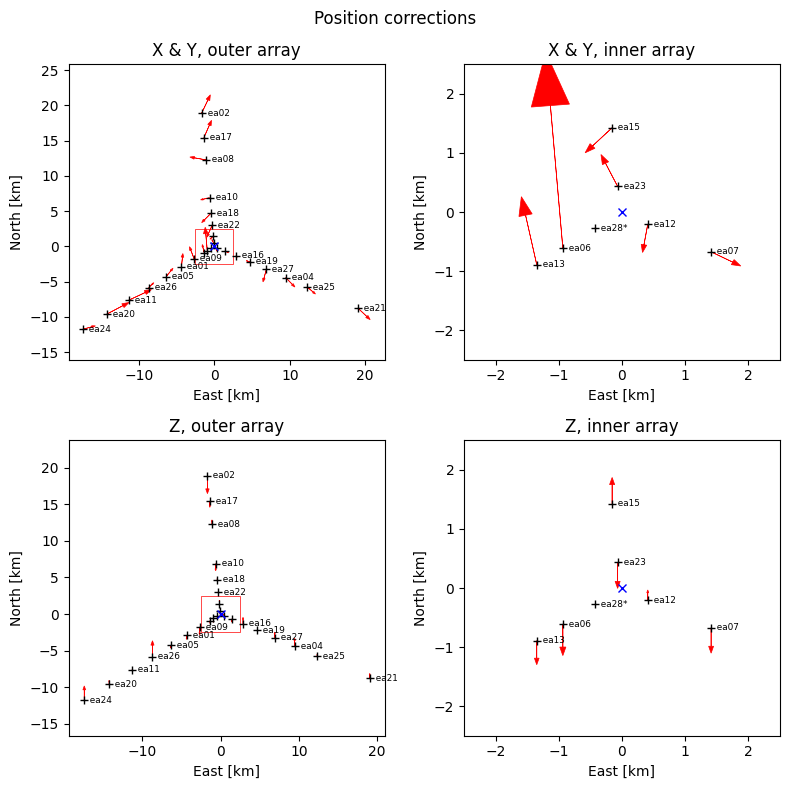

In [18]:
position_mds.plot_position_corrections(
    position_plot_folder,  # Folder to contain plot
    unit="km",  # Unit for the x and Y axes
    box_size=5,  # Size for the box containing the inner array
    scaling=250,  # scaling to be applied to corrections
    display=True,
)

Finally, when we are certain that our results are good we can then export the fit results to an ASCII file that is formatted for input by the VLA parminator software.

In [19]:
position_mds.export_results_to_parminator(
    "ant_pos_cor_24-10-14.PAR",  # name of the output parminator file
    ant=["ea06", "ea01", "ea05"],  # Selected moved antennas
    correction_threshold=0.001,  # Threshold for valid corrections in meters (i.e. minimum value for correction to appear in parminator file)
)

print("Parminator file contents:\n")
for line in open("ant_pos_cor_24-10-14.PAR"):
    print(line[:-1])

[2026-03-05 16:59:47,912]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


Parminator file contents:

W32, ,Y,$ 0.0055
W32, ,Z,$-0.0016
W40, ,X,$ 0.0026
W40, ,Y,$ 0.0034
W40, ,Z,$-0.0011
MAS, ,Y,$ 0.0097
MAS, ,Z,$-0.0015



In [20]:
if parallel:
    client.close()